In [1]:
import pandas as pd

df = pd.read_csv('/content/seasonal_agriculture_performance_dataset.csv')

df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [3]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Shape: (4000, 28)

Columns:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                         

In [4]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [5]:
# Handle missing values using median

df['Rainfall_mm'] = df['Rainfall_mm'].fillna(df['Rainfall_mm'].median())
df['Soil_Moisture_pct'] = df['Soil_Moisture_pct'].fillna(df['Soil_Moisture_pct'].median())
df['Yield_Tonnes_Ha'] = df['Yield_Tonnes_Ha'].fillna(df['Yield_Tonnes_Ha'].median())

# Verify missing values
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,0
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [6]:
# Basic seasonal overview

print("Seasons:")
print(df['Season'].value_counts())

print("\nCrops:")
print(df['Crop'].nunique(), "unique crops")

# Average agricultural performance by season
season_summary = df.groupby('Season').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Production_Tonnes': 'mean',
    'Profit_INR': 'mean',
    'Water_Used_m3': 'mean',
    'Disease_Pest_Risk_pct': 'mean'
}).round(2)

season_summary

Seasons:
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

Crops:
8 unique crops


,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR,Water_Used_m3,Disease_Pest_Risk_pct
Season,,,,,
Kharif,5.63,46.31,178914.65,6102.20,54.47
Rabi,5.04,41.49,87689.47,5846.99,40.48
Zaid,4.64,38.89,-24804.82,6419.89,38.22


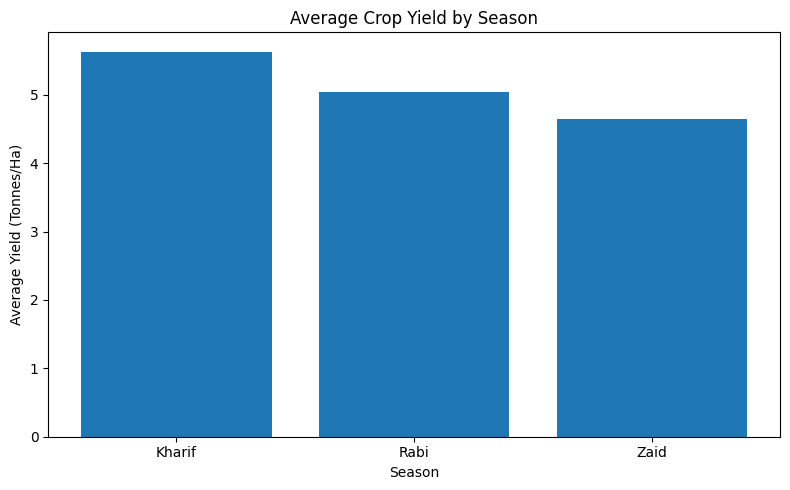

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    season_summary.index,
    season_summary['Yield_Tonnes_Ha']
)

plt.title('Average Crop Yield by Season')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Ha)')

plt.tight_layout()
plt.show()

Season
Kharif    178914.647555
Rabi       87689.470191
Zaid      -24804.824916
Name: Profit_INR, dtype: float64


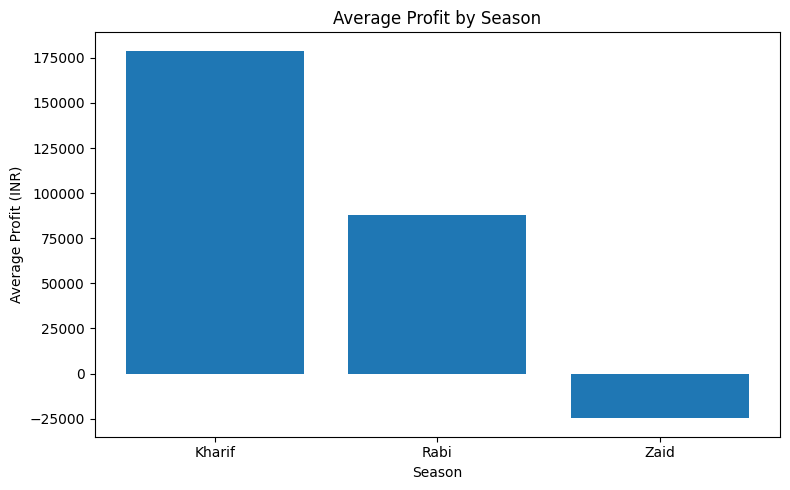

In [8]:
# Average profit by season

profit_by_season = df.groupby('Season')['Profit_INR'].mean().sort_values(ascending=False)

print(profit_by_season)

plt.figure(figsize=(8,5))

plt.bar(
    profit_by_season.index,
    profit_by_season.values
)

plt.title('Average Profit by Season')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')

plt.tight_layout()
plt.show()

Season
Zaid      6419.893939
Kharif    6102.201237
Rabi      5846.987093
Name: Water_Used_m3, dtype: float64


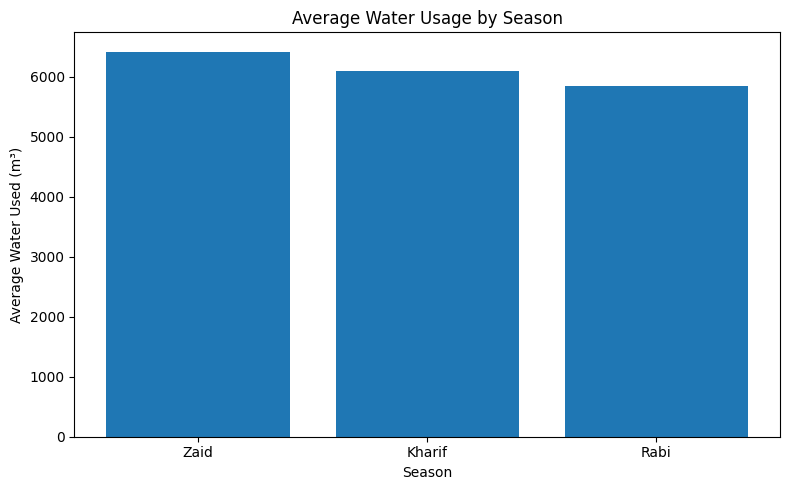

In [9]:
# Average water usage by season

water_by_season = df.groupby('Season')['Water_Used_m3'].mean().sort_values(ascending=False)

print(water_by_season)

plt.figure(figsize=(8,5))

plt.bar(
    water_by_season.index,
    water_by_season.values
)

plt.title('Average Water Usage by Season')
plt.xlabel('Season')
plt.ylabel('Average Water Used (m³)')

plt.tight_layout()
plt.show()

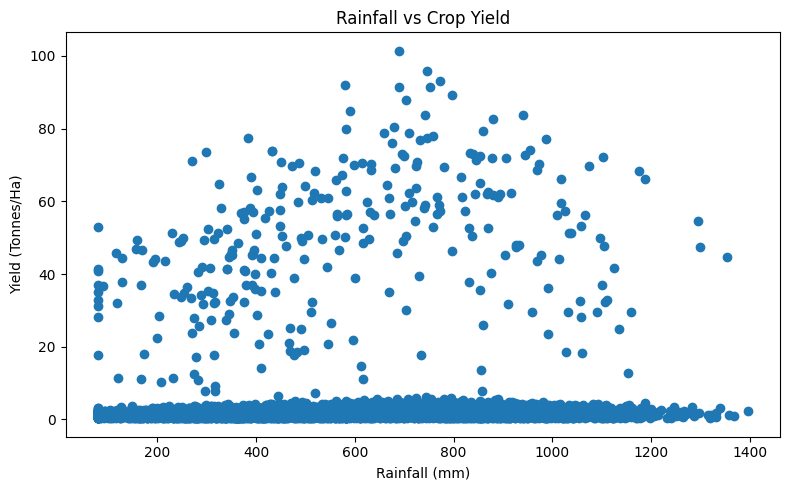

In [10]:
# Relationship between rainfall and crop yield

plt.figure(figsize=(8,5))

plt.scatter(
    df['Rainfall_mm'],
    df['Yield_Tonnes_Ha']
)

plt.title('Rainfall vs Crop Yield')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes/Ha)')

plt.tight_layout()
plt.show()

Season
Kharif    46.311192
Rabi      41.486712
Zaid      38.886111
Name: Production_Tonnes, dtype: float64


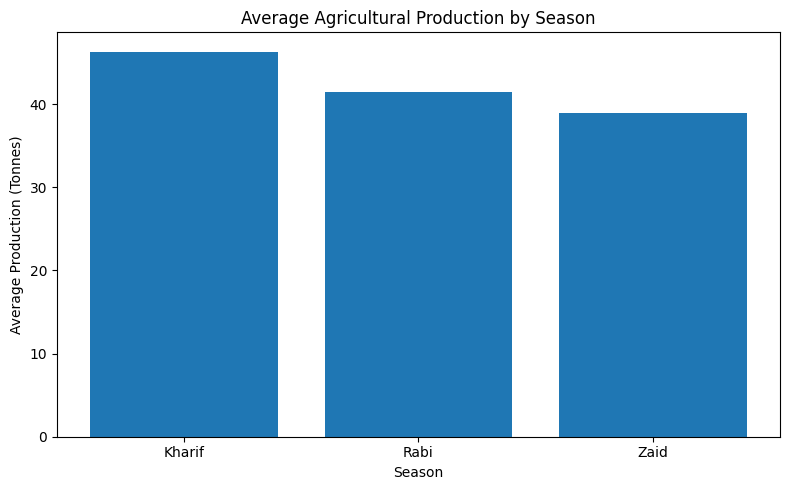

In [11]:
# Average production by season

production_by_season = df.groupby('Season')['Production_Tonnes'].mean().sort_values(ascending=False)

print(production_by_season)

plt.figure(figsize=(8,5))

plt.bar(
    production_by_season.index,
    production_by_season.values
)

plt.title('Average Agricultural Production by Season')
plt.xlabel('Season')
plt.ylabel('Average Production (Tonnes)')

plt.tight_layout()
plt.show()

Season
Kharif    46.311192
Rabi      41.486712
Zaid      38.886111
Name: Production_Tonnes, dtype: float64


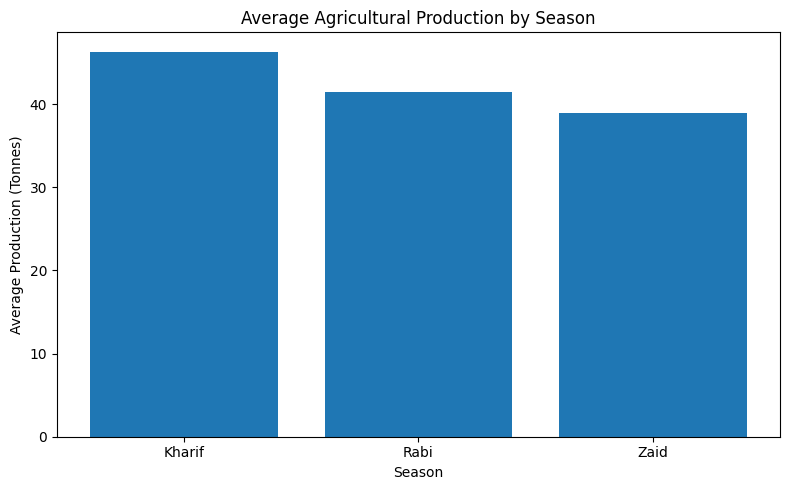

In [12]:
# Average production by season

production_by_season = df.groupby('Season')['Production_Tonnes'].mean().sort_values(ascending=False)

print(production_by_season)

plt.figure(figsize=(8,5))

plt.bar(
    production_by_season.index,
    production_by_season.values
)

plt.title('Average Agricultural Production by Season')
plt.xlabel('Season')
plt.ylabel('Average Production (Tonnes)')

plt.tight_layout()
plt.show()

In [13]:
# Final Project Insights

print("===== FINAL PROJECT INSIGHTS =====")

best_yield_season = season_summary['Yield_Tonnes_Ha'].idxmax()
best_yield = season_summary['Yield_Tonnes_Ha'].max()

best_profit_season = profit_by_season.idxmax()
best_profit = profit_by_season.max()

highest_water_season = water_by_season.idxmax()
highest_water = water_by_season.max()

best_production_season = production_by_season.idxmax()
best_production = production_by_season.max()

print(f"1. Highest average crop yield: {best_yield_season} ({best_yield:.2f} tonnes/ha)")
print(f"2. Highest average profit: {best_profit_season} ({best_profit:.2f} INR)")
print(f"3. Highest average water usage: {highest_water_season} ({highest_water:.2f} m³)")
print(f"4. Highest average production: {best_production_season} ({best_production:.2f} tonnes)")
print("5. Rainfall and crop yield relationship was examined using a scatter plot.")

===== FINAL PROJECT INSIGHTS =====
1. Highest average crop yield: Kharif (5.63 tonnes/ha)
2. Highest average profit: Kharif (178914.65 INR)
3. Highest average water usage: Zaid (6419.89 m³)
4. Highest average production: Kharif (46.31 tonnes)
5. Rainfall and crop yield relationship was examined using a scatter plot.


## Conclusion

The Seasonal Agriculture Performance Analysis examined agricultural performance across Kharif, Rabi and Zaid seasons. The analysis compared crop yield, production, profit and water usage, and examined the relationship between rainfall and crop yield.

The findings provide useful evidence about seasonal differences in agricultural performance and resource usage. These insights can support better seasonal agricultural planning and help identify areas requiring further investigation.